# The Black-Litterman Model
# Investment Management MBA Class Example

## Why Black-Litterman?

In the Treynor-Black notebook, we combined an active portfolio with the market index.
But we treated our alpha estimates as if we *knew* them perfectly.

**Black-Litterman** asks: what if you're not sure about your views?

The model does three things:
1. **Starts from the market** — reverse-engineers what expected returns *must* be if the market portfolio is efficient
2. **Incorporates your views** — lets you express opinions about specific stocks (with a confidence level)
3. **Blends them using Bayes' rule** — more confident views get more weight; less confident views shrink toward the market

The result: sensible, diversified portfolios that tilt toward your views — without the crazy outputs that raw mean-variance optimization produces.

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize
import seaborn as sns
import datetime as dt

# Set styling for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 13

## 1. Get Market Data

We'll use the same stocks as in the Treynor-Black notebook, plus market-cap weights to represent "the market."

In [2]:
# Define our universe
stock_tickers = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META', 'TSLA', 'NVDA', 'JPM', 'V', 'WMT']

# Download 5 years of daily data
end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days=5*365)

prices = yf.download(stock_tickers, start=start_date, end=end_date)['Close']
returns = prices.pct_change().dropna()

print(f"Data from {returns.index[0].date()} to {returns.index[-1].date()}")
print(f"{len(returns)} trading days, {len(stock_tickers)} stocks")

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  10 of 10 completed

Data from 2021-03-30 to 2026-03-26
1254 trading days, 10 stocks


In [3]:
# Get current market caps to construct market-cap weights
market_caps = {}
for ticker in stock_tickers:
    info = yf.Ticker(ticker).info
    market_caps[ticker] = info.get('marketCap', 0)

market_caps = pd.Series(market_caps)
w_mkt = market_caps / market_caps.sum()

print("Market-Cap Weights:")
print("="*35)
for ticker in w_mkt.sort_values(ascending=False).index:
    print(f"  {ticker:5s}  {w_mkt[ticker]:6.1%}")

Market-Cap Weights:
  NVDA    19.6%
  AAPL    17.4%
  GOOGL   15.9%
  MSFT    12.6%
  AMZN    10.5%
  TSLA     6.6%
  META     6.5%
  WMT      4.5%
  JPM      3.6%
  V        2.7%


In [4]:
# Estimate the covariance matrix (annualized)
Sigma = returns.cov() * 252

# Quick sanity check: annualized volatilities
vols = np.sqrt(np.diag(Sigma))
vol_df = pd.DataFrame({'Annualized Vol': vols}, index=stock_tickers)
print(vol_df.sort_values('Annualized Vol', ascending=False).to_string())

       Annualized Vol
JPM          0.590836
NVDA         0.516719
META         0.436009
MSFT         0.352474
AMZN         0.307549
AAPL         0.274555
TSLA         0.261549
GOOGL        0.242672
V            0.224264
WMT          0.210984


## 2. The Problem: Raw MVO Is Broken

Before we get to Black-Litterman, let's see *why* we need it.

If we plug historical sample mean returns into a mean-variance optimizer, what happens?

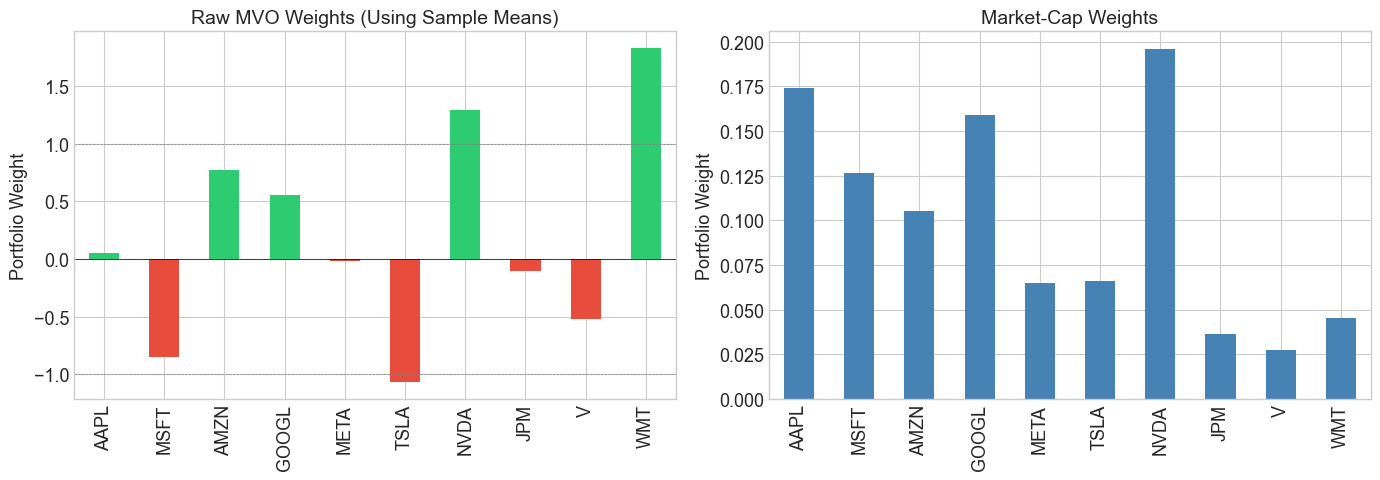


MVO weights range: -106.8% to 182.8%
Sum of absolute weights: 706.9%

⚠️  These weights are not investable. The optimizer is maximizing estimation error.


In [5]:
# Historical sample means (annualized)
mu_sample = returns.mean() * 252
rf = 0.04  # risk-free rate

# Mean-variance optimal weights (unconstrained): w* = (delta * Sigma)^{-1} * (mu - rf)
# We'll use delta = 2.5 (a common risk aversion parameter)
delta = 2.5
w_mvo = np.linalg.solve(delta * Sigma, mu_sample - rf)
w_mvo = pd.Series(w_mvo, index=stock_tickers)

# Display the results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: MVO weights
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in w_mvo]
w_mvo.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Raw MVO Weights (Using Sample Means)', fontsize=14)
axes[0].set_ylabel('Portfolio Weight')
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].axhline(y=1, color='gray', linewidth=0.5, linestyle='--')
axes[0].axhline(y=-1, color='gray', linewidth=0.5, linestyle='--')

# Plot 2: Market cap weights for comparison
w_mkt.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Market-Cap Weights', fontsize=14)
axes[1].set_ylabel('Portfolio Weight')

plt.tight_layout()
plt.show()

print(f"\nMVO weights range: {w_mvo.min():.1%} to {w_mvo.max():.1%}")
print(f"Sum of absolute weights: {w_mvo.abs().sum():.1%}")
print("\n⚠️  These weights are not investable. The optimizer is maximizing estimation error.")

## 3. Step 1 — Reverse Optimization: What Does the Market Believe?

**Key idea:** If the market portfolio is mean-variance efficient (i.e., CAPM holds approximately), then we can *reverse-engineer* the expected returns that would make those market-cap weights optimal.

The formula is simply the first-order condition of MVO, solved for expected returns:

$$\Pi = \delta \cdot \Sigma \cdot w_{mkt}$$

where:
- $\delta$ = risk aversion coefficient
- $\Sigma$ = covariance matrix
- $w_{mkt}$ = market-cap weights

These "implied equilibrium returns" ($\Pi$) are our **starting point** — a sensible baseline before we overlay any views.

In [6]:
# Calibrate risk aversion from market data
# delta = (E[r_m] - r_f) / sigma_m^2
# Use the market-cap weighted portfolio as "the market"
market_return = (returns @ w_mkt).mean() * 252
market_var = float(w_mkt @ Sigma @ w_mkt)
delta = (market_return - rf) / market_var

print(f"Market portfolio return (annualized): {market_return:.2%}")
print(f"Market portfolio volatility:          {np.sqrt(market_var):.2%}")
print(f"Implied risk aversion (delta):        {delta:.2f}")
print()

Market portfolio return (annualized): 28.85%
Market portfolio volatility:          27.07%
Implied risk aversion (delta):        3.39



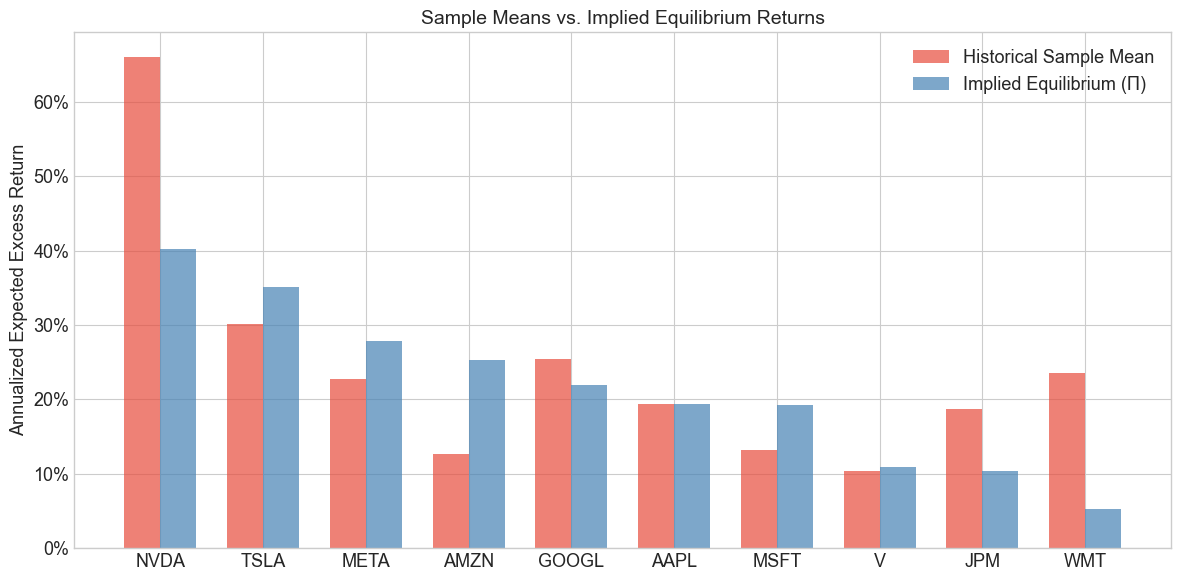


📌 Notice: implied equilibrium returns are much more compressed (reasonable)
   than sample means (which are noisy and dominated by a few big winners).


In [7]:
# Reverse optimization: implied equilibrium excess returns
Pi = delta * Sigma @ w_mkt

# Compare implied returns to sample means
comparison = pd.DataFrame({
    'Sample Mean': mu_sample,
    'Implied Equilibrium (Pi)': Pi
}).sort_values('Implied Equilibrium (Pi)', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison))
width = 0.35
ax.bar(x - width/2, comparison['Sample Mean'], width, label='Historical Sample Mean', color='#e74c3c', alpha=0.7)
ax.bar(x + width/2, comparison['Implied Equilibrium (Pi)'], width, label='Implied Equilibrium (Π)', color='steelblue', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(comparison.index)
ax.set_ylabel('Annualized Expected Excess Return')
ax.set_title('Sample Means vs. Implied Equilibrium Returns', fontsize=14)
ax.legend()
ax.axhline(y=0, color='black', linewidth=0.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()

print("\n📌 Notice: implied equilibrium returns are much more compressed (reasonable)")
print("   than sample means (which are noisy and dominated by a few big winners).")

### What just happened?

The implied returns ($\Pi$) are the market's "consensus" expected returns. They reflect:
- Higher expected returns for riskier (higher-beta, higher-vol) stocks
- Lower expected returns for safer stocks
- No extreme outliers — unlike sample means

**If you stopped here and optimized using $\Pi$, you'd get back the market portfolio.** That's the whole point — the market is our neutral starting position.

Now let's add views.

## 4. Step 2 — Express Your Views (With Confidence)

In Black-Litterman, a "view" has three components:
1. **Which assets** are involved
2. **What you believe** about their returns
3. **How confident** you are

Views can be:
- **Absolute:** "NVDA will return 20% next year"
- **Relative:** "NVDA will outperform AAPL by 5%"

Let's set up two example views.

In [8]:
# ============================================================
# ✏️ EDIT YOUR VIEWS HERE
# ============================================================

# View 1 (Relative): "NVDA will outperform TSLA by 10% over the next year"
# View 2 (Absolute): "WMT will return 12% (excess) next year"

# The "pick matrix" P encodes which stocks are in each view
# Each row is one view. Positive = long, negative = short in that view.
n = len(stock_tickers)
k = 2  # number of views

P = np.zeros((k, n))

# View 1: NVDA outperforms TSLA by 10%
P[0, stock_tickers.index('NVDA')] = 1
P[0, stock_tickers.index('TSLA')] = -1
Q = np.array([0.10,   # View 1: 10% outperformance
              0.12])   # View 2: 12% absolute return

# View 2: WMT absolute return of 12%
P[1, stock_tickers.index('WMT')] = 1

# Display the views
print("Views:")
print("="*60)
view_df = pd.DataFrame(P, columns=stock_tickers, index=['View 1', 'View 2'])
view_df['Expected Return'] = Q
# Only show non-zero columns for clarity
non_zero_cols = [c for c in stock_tickers if (view_df[c] != 0).any()]
print(view_df[non_zero_cols + ['Expected Return']])
print()
print("View 1: NVDA will outperform TSLA by 10%")
print("View 2: WMT will have an excess return of 12%")

Views:
        TSLA  NVDA  WMT  Expected Return
View 1  -1.0   1.0  0.0             0.10
View 2   0.0   0.0  1.0             0.12

View 1: NVDA will outperform TSLA by 10%
View 2: WMT will have an excess return of 12%


### Setting View Confidence

Each view has an associated **uncertainty** ($\omega$). Higher $\omega$ = less confident.

A common calibration (He & Litterman, 1999): set each view's uncertainty proportional to the variance implied by those assets:

$$\Omega = \text{diag}(P \cdot (\tau\Sigma) \cdot P')$$

This says: "my view is about as uncertain as the equilibrium would suggest for these assets."

We'll also show what happens when you manually set high or low confidence.

In [9]:
# tau controls uncertainty in the equilibrium mean
# Think of it as: "how confident am I that the market is right?"
# Small tau = very confident in market; large tau = less confident
tau = 0.05

# Calibrate view uncertainty using He & Litterman (1999) approach
Omega = np.diag(np.diag(P @ (tau * Sigma) @ P.T))

print(f"tau = {tau}")
print(f"\nView uncertainty (Omega diagonal):")
for i in range(k):
    print(f"  View {i+1}: omega = {Omega[i,i]:.4f}  (std dev = {np.sqrt(Omega[i,i]):.2%})")

tau = 0.05

View uncertainty (Omega diagonal):
  View 1: omega = 0.0085  (std dev = 9.22%)
  View 2: omega = 0.0022  (std dev = 4.72%)


## 5. Step 3 — Bayesian Update: Blend Market + Views

Now we combine the equilibrium returns (prior) with our views (likelihood) using Bayes' rule.

The **posterior expected returns** are:

$$\hat{\mu} = \Pi + \tau\Sigma P' \left( P \tau\Sigma P' + \Omega \right)^{-1} (Q - P\Pi)$$

This is equivalent to the precision-weighted formula, but written in a more intuitive form:

> **Posterior = Equilibrium + Adjustment**
>
> where the adjustment depends on how much your views *differ* from equilibrium, scaled by your confidence.

In [10]:
def black_litterman(Pi, Sigma, P, Q, Omega, tau):
    """
    Compute Black-Litterman posterior expected returns.
    
    Parameters
    ----------
    Pi    : array (n,)   - Implied equilibrium excess returns
    Sigma : array (n, n) - Covariance matrix of returns
    P     : array (k, n) - Pick matrix (views on assets)
    Q     : array (k,)   - View expected returns
    Omega : array (k, k) - View uncertainty matrix
    tau   : float         - Scalar uncertainty on equilibrium
    
    Returns
    -------
    mu_bl      : array (n,) - Posterior expected returns
    Sigma_bl   : array (n,n) - Posterior covariance of the mean
    """
    tau_Sigma = tau * Sigma
    
    # The "middle" matrix
    M = P @ tau_Sigma @ P.T + Omega  # (k x k)
    M_inv = np.linalg.inv(M)
    
    # Posterior mean (equivalent form that's more intuitive)
    mu_bl = Pi + tau_Sigma @ P.T @ M_inv @ (Q - P @ Pi)
    
    # Posterior covariance of the mean
    Sigma_bl = tau_Sigma - tau_Sigma @ P.T @ M_inv @ P @ tau_Sigma
    
    return mu_bl, Sigma_bl

In [11]:
# Run Black-Litterman
mu_bl, Sigma_bl = black_litterman(Pi.values, Sigma.values, P, Q, Omega, tau)
mu_bl = pd.Series(mu_bl, index=stock_tickers)

# Compare: Equilibrium vs. BL posterior
comparison = pd.DataFrame({
    'Equilibrium (Π)': Pi,
    'BL Posterior (μ̂)': mu_bl,
    'Difference': mu_bl - Pi
}).sort_values('BL Posterior (μ̂)', ascending=False)

print(comparison.to_string(float_format=lambda x: f'{x:.2%}'))

       Equilibrium (Π)  BL Posterior (μ̂)  Difference
NVDA            40.21%             35.16%      -5.05%
JPM             10.41%             34.13%      23.72%
META            27.82%             27.48%      -0.34%
MSFT            19.20%             25.18%       5.98%
AMZN            25.23%             21.80%      -3.43%
TSLA            35.08%             19.65%     -15.44%
AAPL            19.37%             19.64%       0.27%
V               10.84%             11.23%       0.39%
GOOGL           21.99%             10.58%     -11.40%
WMT              5.22%              8.60%       3.39%


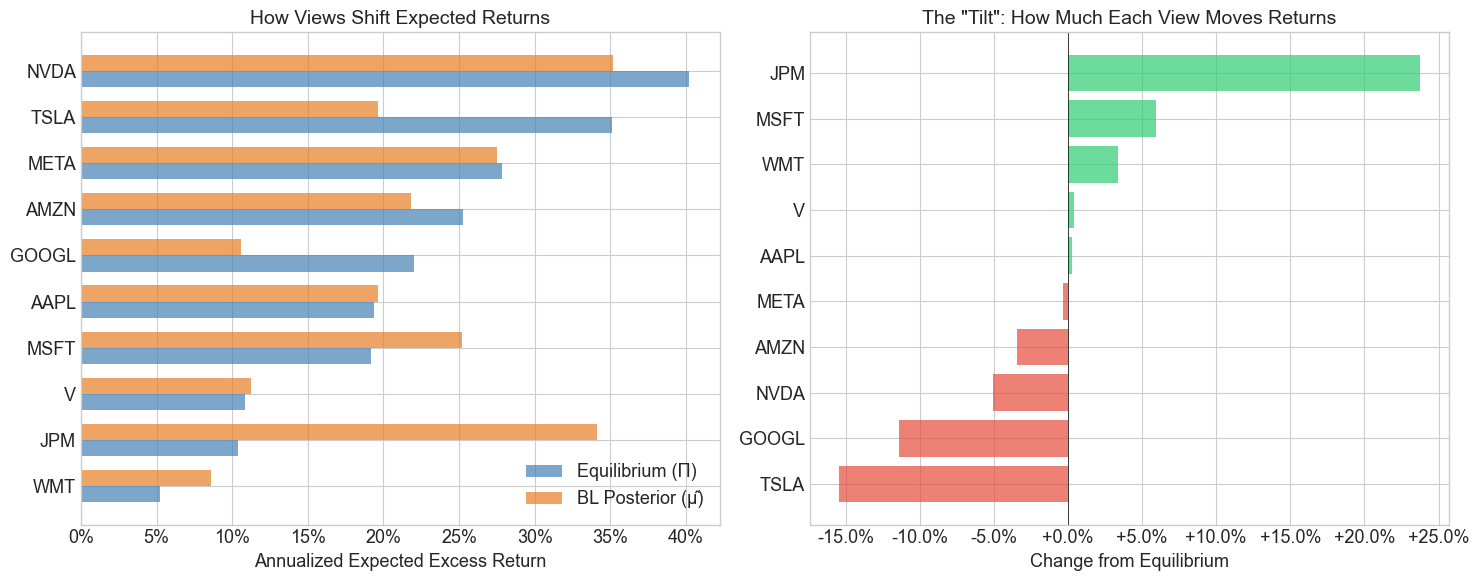

📌 Key insight: the views shift returns for stocks you DIDN'T mention too!
   This is because the covariance structure propagates your views to correlated assets.


In [12]:
# Visualize: how views shift returns
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left panel: side-by-side comparison
comp_sorted = comparison.sort_values('Equilibrium (Π)', ascending=True)
y = np.arange(len(comp_sorted))
height = 0.35

axes[0].barh(y - height/2, comp_sorted['Equilibrium (Π)'], height, 
             label='Equilibrium (Π)', color='steelblue', alpha=0.7)
axes[0].barh(y + height/2, comp_sorted['BL Posterior (μ̂)'], height,
             label='BL Posterior (μ̂)', color='#e67e22', alpha=0.7)
axes[0].set_yticks(y)
axes[0].set_yticklabels(comp_sorted.index)
axes[0].set_xlabel('Annualized Expected Excess Return')
axes[0].set_title('How Views Shift Expected Returns', fontsize=14)
axes[0].legend(loc='lower right')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# Right panel: the "tilt" — difference from equilibrium
diff_sorted = comparison.sort_values('Difference')
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in diff_sorted['Difference']]
axes[1].barh(diff_sorted.index, diff_sorted['Difference'], color=colors, alpha=0.7)
axes[1].set_xlabel('Change from Equilibrium')
axes[1].set_title('The "Tilt": How Much Each View Moves Returns', fontsize=14)
axes[1].axvline(x=0, color='black', linewidth=0.5)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:+.1%}'))

plt.tight_layout()
plt.show()

print("📌 Key insight: the views shift returns for stocks you DIDN'T mention too!")
print("   This is because the covariance structure propagates your views to correlated assets.")

## 6. Step 4 — Optimal Portfolio Weights

Now we feed the BL posterior returns into the mean-variance optimizer.

$$w^* = (\delta \Sigma)^{-1} \hat{\mu}$$

We'll compare three portfolios:
1. **Raw MVO** (using sample means) — the broken version
2. **BL with no views** — should recover the market portfolio
3. **BL with our views** — market portfolio + sensible tilts

In [13]:
# BL with no views: should give back market portfolio
mu_no_views = Pi  # no views means posterior = prior
w_no_views = pd.Series(np.linalg.solve(delta * Sigma, mu_no_views), index=stock_tickers)

# BL with views
w_bl = pd.Series(np.linalg.solve(delta * Sigma, mu_bl), index=stock_tickers)

# Raw MVO (from sample means) — already computed above as w_mvo

# Compare all three
weights_comparison = pd.DataFrame({
    'Market-Cap': w_mkt,
    'BL (No Views)': w_no_views,
    'BL (With Views)': w_bl,
    'Raw MVO': w_mvo
}).round(4)

print(weights_comparison.to_string(float_format=lambda x: f'{x:.2%}'))

       Market-Cap  BL (No Views)  BL (With Views)  Raw MVO
AAPL       17.41%         17.41%           17.41%    5.48%
MSFT       12.62%         10.50%           10.50%  -85.20%
AMZN       10.50%         15.91%           15.91%   77.23%
GOOGL      15.91%          3.65%            3.65%   55.75%
META        6.50%          6.50%            6.50%   -1.27%
TSLA        6.58%         12.62%           22.19% -106.78%
NVDA       19.60%         19.60%           10.03%  129.47%
JPM         3.65%          6.58%            6.58%  -10.58%
V           2.72%          2.72%            2.72%  -52.28%
WMT         4.52%          4.52%           27.01%  182.82%


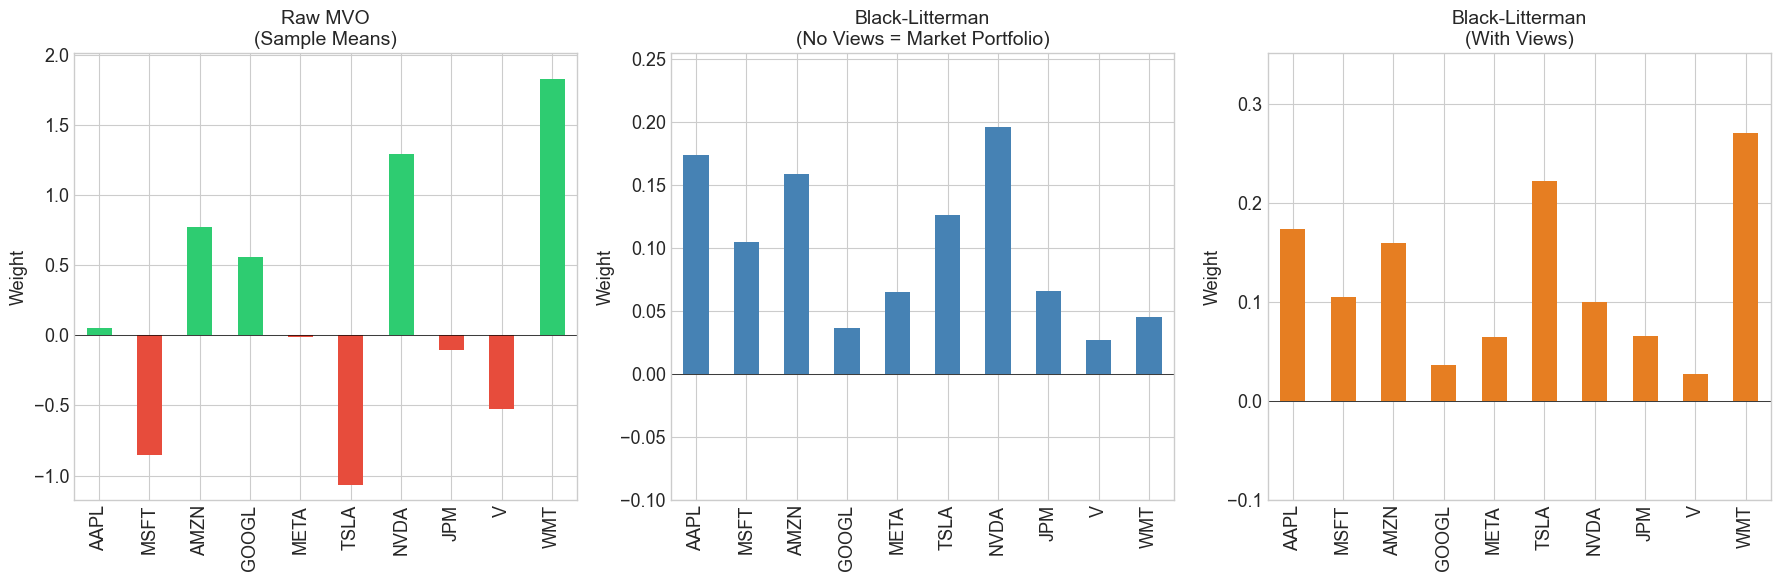

📌 Notice:
   - Raw MVO: extreme, uninvestable weights
   - BL (no views): recovers market-cap weights exactly
   - BL (with views): market portfolio + sensible tilts toward our views


In [14]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: Raw MVO
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in w_mvo]
w_mvo.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Raw MVO\n(Sample Means)', fontsize=14)
axes[0].set_ylabel('Weight')
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].set_ylim(min(w_mvo.min() * 1.1, -0.5), max(w_mvo.max() * 1.1, 0.5))

# Panel 2: BL with no views (= market portfolio)
w_no_views.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Black-Litterman\n(No Views = Market Portfolio)', fontsize=14)
axes[1].set_ylabel('Weight')
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_ylim(-0.1, w_no_views.max() * 1.3)

# Panel 3: BL with views
w_bl.plot(kind='bar', ax=axes[2], color='#e67e22')
axes[2].set_title('Black-Litterman\n(With Views)', fontsize=14)
axes[2].set_ylabel('Weight')
axes[2].axhline(y=0, color='black', linewidth=0.5)
axes[2].set_ylim(-0.1, w_bl.max() * 1.3)

plt.tight_layout()
plt.show()

print("📌 Notice:")
print("   - Raw MVO: extreme, uninvestable weights")
print("   - BL (no views): recovers market-cap weights exactly")
print("   - BL (with views): market portfolio + sensible tilts toward our views")

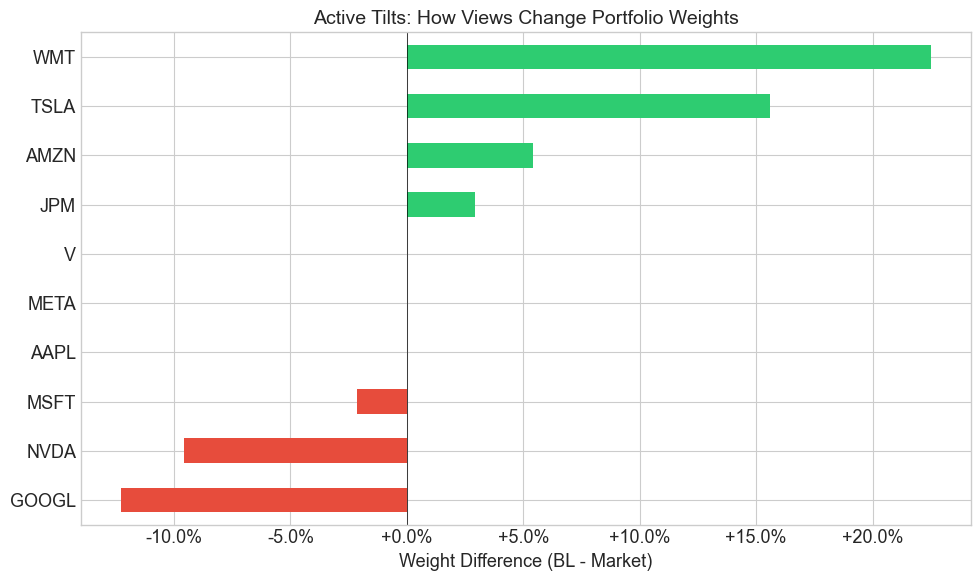


These tilts are the 'active bets' — what you're paying an active manager for.
Sum of absolute tilts (2 × Active Share): 70.38%


In [15]:
# Show the tilt: difference between BL weights and market weights
tilt = w_bl - w_mkt
tilt_sorted = tilt.sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in tilt_sorted]
tilt_sorted.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Weight Difference (BL - Market)')
ax.set_title('Active Tilts: How Views Change Portfolio Weights', fontsize=14)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:+.1%}'))
plt.tight_layout()
plt.show()

print("\nThese tilts are the 'active bets' — what you're paying an active manager for.")
print(f"Sum of absolute tilts (2 × Active Share): {tilt.abs().sum():.2%}")

## 7. How Confidence Changes Everything

The power of Black-Litterman is that **confidence matters as much as the view itself.**

Let's see what happens when we vary our confidence in View 1 (NVDA outperforms TSLA by 10%).

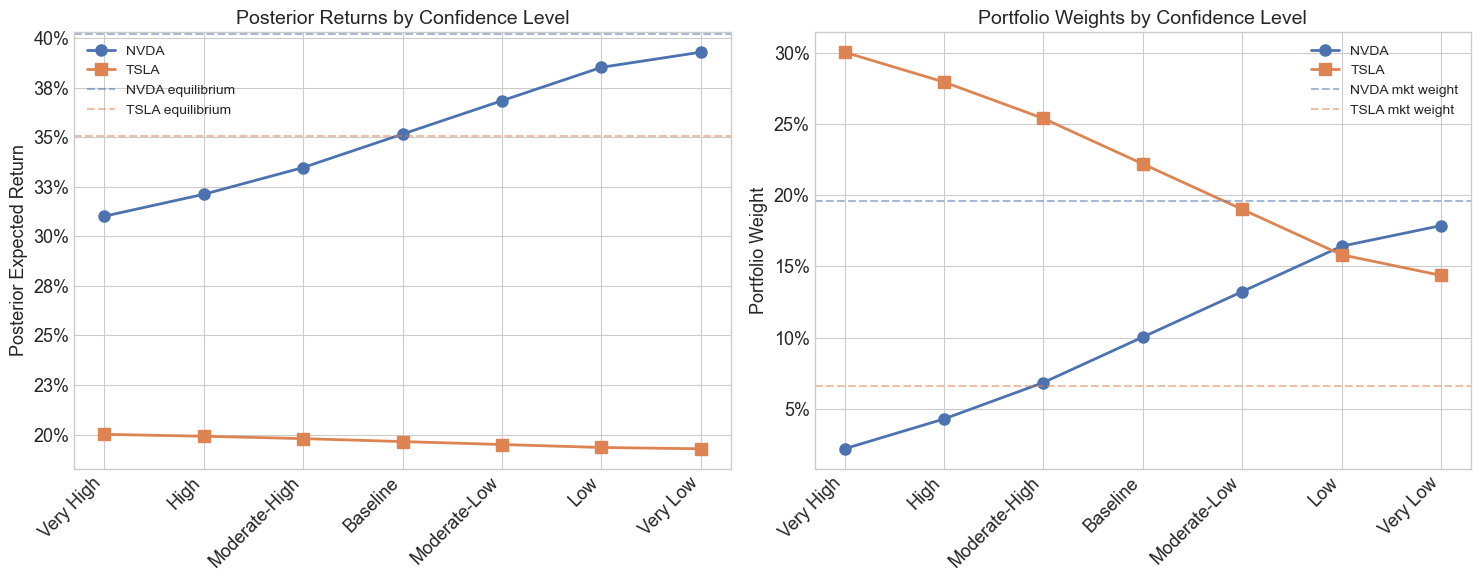

📌 As confidence decreases (right), posterior returns → equilibrium and weights → market cap.
   As confidence increases (left), the portfolio tilts more aggressively toward your view.


In [16]:
# Vary confidence from very low to very high
# We'll scale Omega by a "confidence multiplier"
# multiplier < 1 means MORE confident, > 1 means LESS confident
confidence_levels = [0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0]
confidence_labels = ['Very High', 'High', 'Moderate-High', 'Baseline', 'Moderate-Low', 'Low', 'Very Low']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

nvda_returns = []
tsla_returns = []
nvda_weights = []
tsla_weights = []

for mult in confidence_levels:
    Omega_scaled = Omega * mult
    mu_temp, _ = black_litterman(Pi.values, Sigma.values, P, Q, Omega_scaled, tau)
    mu_temp = pd.Series(mu_temp, index=stock_tickers)
    w_temp = pd.Series(np.linalg.solve(delta * Sigma, mu_temp), index=stock_tickers)
    
    nvda_returns.append(mu_temp['NVDA'])
    tsla_returns.append(mu_temp['TSLA'])
    nvda_weights.append(w_temp['NVDA'])
    tsla_weights.append(w_temp['TSLA'])

# Left panel: posterior returns
axes[0].plot(range(len(confidence_levels)), nvda_returns, 'o-', label='NVDA', linewidth=2, markersize=8)
axes[0].plot(range(len(confidence_levels)), tsla_returns, 's-', label='TSLA', linewidth=2, markersize=8)
axes[0].axhline(y=Pi['NVDA'], color='C0', linestyle='--', alpha=0.5, label='NVDA equilibrium')
axes[0].axhline(y=Pi['TSLA'], color='C1', linestyle='--', alpha=0.5, label='TSLA equilibrium')
axes[0].set_xticks(range(len(confidence_levels)))
axes[0].set_xticklabels(confidence_labels, rotation=45, ha='right')
axes[0].set_ylabel('Posterior Expected Return')
axes[0].set_title('Posterior Returns by Confidence Level', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Right panel: portfolio weights
axes[1].plot(range(len(confidence_levels)), nvda_weights, 'o-', label='NVDA', linewidth=2, markersize=8)
axes[1].plot(range(len(confidence_levels)), tsla_weights, 's-', label='TSLA', linewidth=2, markersize=8)
axes[1].axhline(y=w_mkt['NVDA'], color='C0', linestyle='--', alpha=0.5, label='NVDA mkt weight')
axes[1].axhline(y=w_mkt['TSLA'], color='C1', linestyle='--', alpha=0.5, label='TSLA mkt weight')
axes[1].set_xticks(range(len(confidence_levels)))
axes[1].set_xticklabels(confidence_labels, rotation=45, ha='right')
axes[1].set_ylabel('Portfolio Weight')
axes[1].set_title('Portfolio Weights by Confidence Level', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()

print("📌 As confidence decreases (right), posterior returns → equilibrium and weights → market cap.")
print("   As confidence increases (left), the portfolio tilts more aggressively toward your view.")

## 8. Try Your Own Views

Here's a function that makes it easy to experiment. Specify views in plain English and see what happens.

In [17]:
def run_black_litterman(views, tau=0.05, confidence='baseline'):
    """
    Run Black-Litterman with user-specified views.
    
    Parameters
    ----------
    views : list of dicts, each with keys:
        'long'  : str or None — ticker to go long
        'short' : str or None — ticker to go short (for relative views)
        'return': float — expected return (excess, annualized)
    tau : float
    confidence : str — 'very_high', 'high', 'baseline', 'low', 'very_low'
    
    Example
    -------
    views = [
        {'long': 'NVDA', 'short': 'TSLA', 'return': 0.10},  # relative
        {'long': 'WMT', 'short': None, 'return': 0.12},     # absolute
    ]
    """
    conf_map = {'very_high': 0.1, 'high': 0.25, 'baseline': 1.0, 'low': 5.0, 'very_low': 10.0}
    conf_mult = conf_map.get(confidence, 1.0)
    
    k = len(views)
    n = len(stock_tickers)
    P_local = np.zeros((k, n))
    Q_local = np.zeros(k)
    
    for i, v in enumerate(views):
        if v['long'] is not None:
            P_local[i, stock_tickers.index(v['long'])] = 1
        if v.get('short') is not None:
            P_local[i, stock_tickers.index(v['short'])] = -1
        Q_local[i] = v['return']
    
    Omega_local = np.diag(np.diag(P_local @ (tau * Sigma.values) @ P_local.T)) * conf_mult
    mu_post, _ = black_litterman(Pi.values, Sigma.values, P_local, Q_local, Omega_local, tau)
    mu_post = pd.Series(mu_post, index=stock_tickers)
    w_post = pd.Series(np.linalg.solve(delta * Sigma, mu_post), index=stock_tickers)
    
    # --- Plot ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Panel 1: Returns comparison
    comp = pd.DataFrame({'Equilibrium': Pi, 'BL Posterior': mu_post}).sort_values('BL Posterior')
    y = np.arange(len(comp))
    h = 0.35
    axes[0].barh(y - h/2, comp['Equilibrium'], h, label='Equilibrium', color='steelblue', alpha=0.7)
    axes[0].barh(y + h/2, comp['BL Posterior'], h, label='BL Posterior', color='#e67e22', alpha=0.7)
    axes[0].set_yticks(y)
    axes[0].set_yticklabels(comp.index)
    axes[0].legend()
    axes[0].set_title('Expected Returns')
    axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    
    # Panel 2: Weights
    w_comp = pd.DataFrame({'Market': w_mkt, 'BL': w_post}).sort_values('BL')
    y2 = np.arange(len(w_comp))
    axes[1].barh(y2 - h/2, w_comp['Market'], h, label='Market-Cap', color='steelblue', alpha=0.7)
    axes[1].barh(y2 + h/2, w_comp['BL'], h, label='BL Optimal', color='#e67e22', alpha=0.7)
    axes[1].set_yticks(y2)
    axes[1].set_yticklabels(w_comp.index)
    axes[1].legend()
    axes[1].set_title('Portfolio Weights')
    axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    
    # Panel 3: Active tilts
    tilt = (w_post - w_mkt).sort_values()
    colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in tilt]
    axes[2].barh(tilt.index, tilt.values, color=colors, alpha=0.7)
    axes[2].set_title('Active Tilts')
    axes[2].axvline(x=0, color='black', linewidth=0.5)
    axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:+.1%}'))
    
    plt.suptitle(f'Black-Litterman Results (confidence: {confidence})', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()
    
    return mu_post, w_post

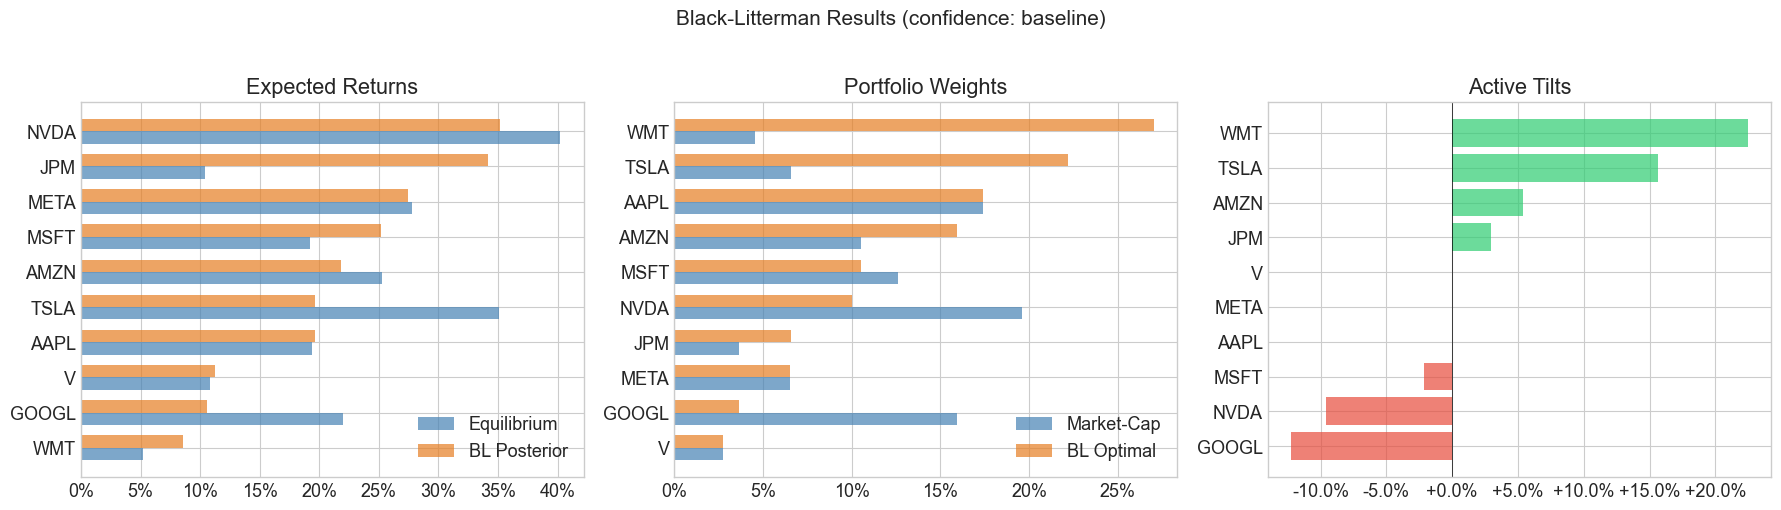

In [18]:
# Example: try your own views!
my_views = [
    {'long': 'NVDA', 'short': 'TSLA', 'return': 0.10},   # NVDA beats TSLA by 10%
    {'long': 'WMT', 'short': None, 'return': 0.12},      # WMT returns 12%
]

mu_post, w_post = run_black_litterman(my_views, confidence='baseline')

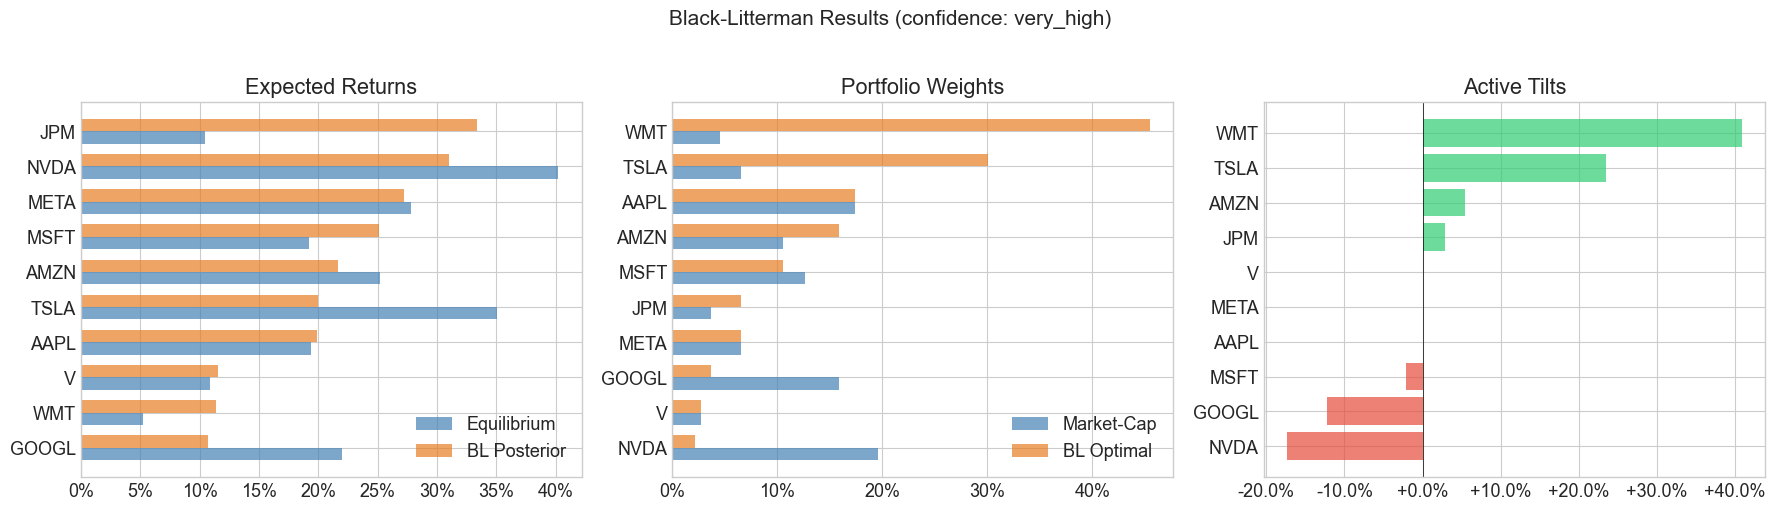

In [19]:
# Same views, but very high confidence
mu_post_hi, w_post_hi = run_black_litterman(my_views, confidence='very_high')

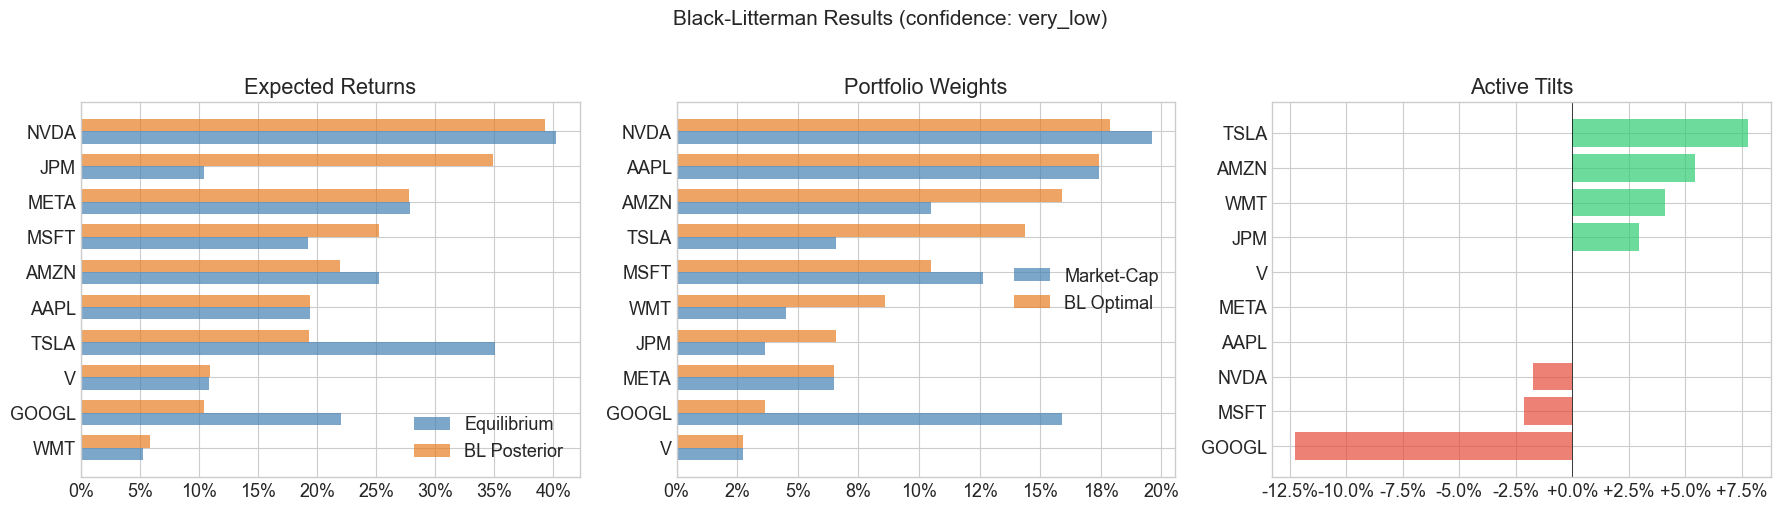

In [20]:
# Same views, but very low confidence
mu_post_lo, w_post_lo = run_black_litterman(my_views, confidence='very_low')

## 9. Summary: Why Black-Litterman Matters

| Feature | Raw MVO | Treynor-Black | Black-Litterman |
|---------|---------|---------------|------------------|
| Starting point | Sample means | CAPM + alpha views | Market equilibrium |
| Handles uncertainty in views? | No | No | **Yes** |
| No views → ? | Garbage | Market portfolio | **Market portfolio** |
| Typical output | Extreme, uninvestable | Reasonable | **Reasonable + tunable** |
| Used in practice? | Rarely (unconstrained) | Sometimes | **Widely** (Goldman, etc.) |

### Key Takeaways

1. **Start from the market.** The market portfolio is your "GPS" — a sensible default.

2. **Views tilt, not replace.** Your opinions shift the portfolio away from the market *proportionally to your confidence.*

3. **Covariance propagates views.** A view on NVDA changes expected returns for correlated stocks like MSFT and GOOGL.

4. **Confidence matters as much as the view.** A 20% return forecast with low confidence barely moves the needle.

5. **Connection to Active Share:** The BL portfolio tilts *are* your active positions. The sum of absolute tilts is related to your Active Share — the topic we discuss in the next part of class.

---

### Further Reading
- **Original paper:** Black, F. and Litterman, R. (1992). "Global Portfolio Optimization." *Financial Analysts Journal.*
- **Practitioner guide:** He, G. and Litterman, R. (1999). "The Intuition Behind Black-Litterman Model Portfolios." Goldman Sachs.
- **Interactive tutorial:** [QuantEcon: Black-Litterman](https://python-advanced.quantecon.org/black_litterman.html) (already linked in the lecture slides)
- **Generalization:** Meucci, A. (2008). "The Black-Litterman Approach: Original Model and Extensions." *Encyclopedia of Quantitative Finance.*